# The upside gap two crows — does an unfilled gap really mark the top? 🐦‍⬛🕳️
### One of the rarest, most dramatic-looking three-candle patterns in the candlestick canon, measured on 21.5 years of real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Marks_a_top%3F: Busted](https://img.shields.io/badge/Marks_a_top%3F-Busted-8b949e?style=flat-square)

Open a candlestick book to the obscure section and you'll meet the **upside gap two crows**: after a rally, a bullish (white) day, then a black day that **gaps up** away from it — a fresh high, bulls apparently still in charge — but the very next day is *another* black candle that opens even higher and closes lower, chewing into the first black candle's body. Two "crows" have now landed on the gap and are digging into it — yet **they can't quite close it**. That unresolved tension is read as exhaustion: the rally has run out of buyers, and the top is in. Sell, or short.

It's one of the rarer named patterns — and rarity is exactly why chartists love it: it *feels* special when you spot one. So we did the boring, honest thing: found **every** upside gap two crows in a basket of 30 big US stocks + SPY over 21.5 years, and measured what actually happened next.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the Bonferroni correction? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name liquid large-cap + SPY** basket (names still trading today), so this carries **survivorship** (we can't include firms that actually *did* top out, crash and delist). If anything that should make the "top" signal look **stronger** than reality — and it still doesn't show up. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from upside_gap_two_crows import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': 'b1038f477d11', 'fp_basket': '67c54c8a3aa2', 'total_bars': 162180, 'h1': (1, 239, 0.013, 0.028, 46, 48, 0.18, 0.17, 0.55, 0.435, -0.089, -0.189), 'h5': (5, 239, -0.151, 0.252, 46, 45, -0.86, -0.77, 0.52, 0.738, -0.261, -0.361), 'h10': (10, 239, -0.532, 0.529, 44, 43, -1.65, -1.75, -0.01, 0.951, -0.652, -0.752), 'hit_wilson': {1: (39.8, 52.4), 5: (39.8, 52.4), 10: (37.8, 50.3)}, 'strict': [(1, 66, 0.077, 0.83, 0.56, 0.321, -0.025), (5, 66, -0.215, 0.12, -0.67, 0.699, -0.325), (10, 66, -0.873, -0.65, -1.7, 0.922, -0.993)], 'trend': [(1, 136, -0.009, 0.17, -0.09, 0.528, -0.111), (5, 136, -0.169, 0.36, -0.9, 0.698, -0.279), (10, 136, -0.352, 0.43, -0.92, 0.786, -0.472)], 'bonf_k': 26, 'bonf_z': 3.1, 'bonf_survive': 0, 'bonf_top': [('XOM', 10, -1.573, -2.01), ('ORCL', 11, 1.353, 1.75), ('INTC', 7, 1.997, 1.58)], 'syn_null_mean': 0.09, 'syn_null_sd': 1.28, 'syn_null_fire': 2, 'syn_null_n': 20, 'syn': [(0.0, 98, 98, -0.709, -1.43, -2.59, 0.978, 39), (0.012, 98, 98, 0.505, 2.38, 1.85, 0.068, 56), (0.02, 98, 98, 1.306, 4.94, 4.78, 0.0, 63)]}


real basket cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After an upside gap two crows, does the stock keep falling? | **No — not in any way we can certify.** Short it the next morning and, on average, over the next 1–10 days you're roughly flat-to-losing once compared fairly to an ordinary day. The "top" doesn't reliably arrive. |
| So the average short return being negative at 5–10 days means something, right? | **No — that's the market's own tide, not the pattern.** This basket drifts up on average (stocks generally do), so shorting *anything* — even random days — tends to lose against zero. The fair test is against what the *same basket* does on a normal day, and against that fair bar the pattern shows **nothing**. |
| Does the picture-perfect version (a true, full-range gap, no overlap at all) work better? | **No.** It doesn't sharpen the signal — the strict shape is just rarer. |
| What if I only count patterns after a genuine uptrend (a real "reversal")? | **Still nothing.** |
| Does any single stock secretly carry the pattern? | **No.** Checked individually across all 26 names with enough events, using a stricter statistical bar (so one lucky name can't pass as "the" signal), **0/26** clear it — and the two loudest names don't even agree on direction. |

> One of the rarest, most photogenic patterns in the book is, on the tape, indistinguishable from an ordinary day — and shorting it **loses money** after costs at every horizon.

## 1 · The claim

> *"The **upside gap two crows** is a bearish reversal. After a rally: a bullish candle, then a black candle that **gaps up** away from it, then a second black candle that opens even higher and closes lower — digging into the gap but **failing to close it**. The bulls gapped it higher, the bears are now clawing it back, but the tug-of-war stays unresolved. That's exhaustion — the top is in."*

This is straight out of Steve Nison's *Japanese Candlestick Charting Techniques* (the book that brought candles to the West) and is catalogued in Thomas Bulkowski's *Encyclopedia of Candlestick Charts* — where, notably, even Bulkowski's own screens rank it near the bottom of his reliability tables. We measure it independently, on our own basket and protocol, and ask the only question that matters: **does the drop come?**

## 2 · So what?

If the upside gap two crows really marked tops, it would be a rare but valuable signal: a clean, eyeball-able warning — visible only a handful of times a year per stock — that a rally has topped out and it's time to trim or short.

But there's a trap built into the very shape of the pattern. The confirming candle is, almost by definition, the second of **two consecutive down days** after an initial spike. Markets that just fell twice in a row tend to **bounce** (short-term mean reversion), not keep tumbling. So a naive short right after the second crow might be picking a fight with the market's own rebound tendency — the exact opposite of what the folklore promises. We'll see which force wins, and — just as important — whether "the short loses" is a *real* bearish-fighting-force or just the ordinary tide of an up-drifting market.

## 3 · How would we even know?

We take a fixed **30-name** basket of liquid US large-caps + **SPY** and scan every daily bar from **2005-01-03** to **2026-06-30** (21.5 years). For each name we flag **every** upside gap two crows with a precise OHLC rule (bullish body, then a black body gapping up from it, then a second black body opening higher and closing lower than the first — engulfing it from above — while staying above the first candle's close). Then, with **no cheating**:

1. **Wait for the close** that confirms the second crow.
2. **Enter the next morning's open** (one day's lag — you can't trade a bar still forming) and hold **1, 5, or 10** trading days, **short** (the bearish bet).
3. **Compare fairly** — not to zero (a naive comparison is fooled by the market's own upward drift), but to what the *same basket* earns on an unconditional day, and to thousands of random "fake signal" picks. If shorting the crows beats the everyday tide, the legend is real. If it doesn't, the top is a myth.

## 4 · The teardown — let's actually look

**First, the headline.** Here's the signed-short return after an upside gap two crows, at each horizon, next to what the *same basket* earns on an ordinary (unconditional) day. A real "top" signal would show the pattern's bar **beating** the baseline, in green.

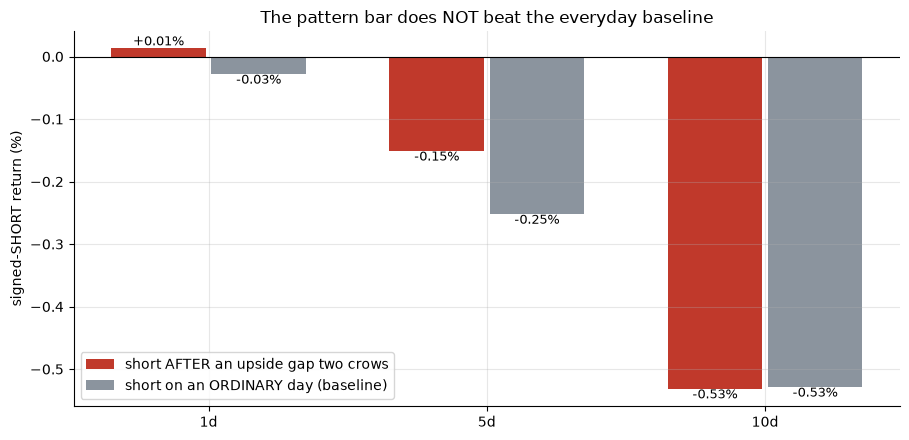

after upside gap two crows: {'1d': 0.013, '5d': -0.151, '10d': -0.532}
ordinary day (same bet): {'1d': -0.028, '5d': -0.252, '10d': -0.529}


In [2]:
hs = [1, 5, 10]
if HAVE_REAL:
    rows = {h: st.summarize(PANEL, h, placebo=False) for h in hs}
    means = [rows[h]['mean']*100 for h in hs]
    base  = [-rows[h]['base_mean']*100 for h in hs]   # base, expressed as the SAME short bet
else:
    means = [R['h1'][2], R['h5'][2], R['h10'][2]]
    base  = [-R['h1'][3], -R['h5'][3], -R['h10'][3]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x-.18, means, .34, color=RED, label='short AFTER an upside gap two crows')
ax.bar(x+.18, base, .34, color=GREY, label='short on an ORDINARY day (baseline)')
for i,v in enumerate(means): ax.annotate(f'{v:+.2f}%',(i-.18,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
for i,v in enumerate(base): ax.annotate(f'{v:+.2f}%',(i+.18,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('signed-SHORT return (%)')
ax.set_title('The pattern bar does NOT beat the everyday baseline')
ax.legend(); plt.tight_layout(); plt.show()
print('after upside gap two crows:', {f'{h}d': round(m,3) for h,m in zip(hs,means)})
print('ordinary day (same bet):', {f'{h}d': round(b,3) for h,b in zip(hs,base)})

At 10 days the pattern short is **-0.53%** vs **-0.53%** for an ordinary day's short — both negative, and roughly the same shade of red. That's the tell: the pattern isn't adding bearish information beyond the market's own up-drift. The "significant-looking" negative number you'd get by comparing the pattern's short to **zero** is a mirage created by the tide, not the crows.

**Could it just be luck?** Let's pit the real signal against thousands of **fake** ones: pick the same number of random days, flip a coin for long/short, and see how the real pattern's return stacks up. If the crows had real bearish power, the real result would sit far in the tail (better than almost all the fakes).

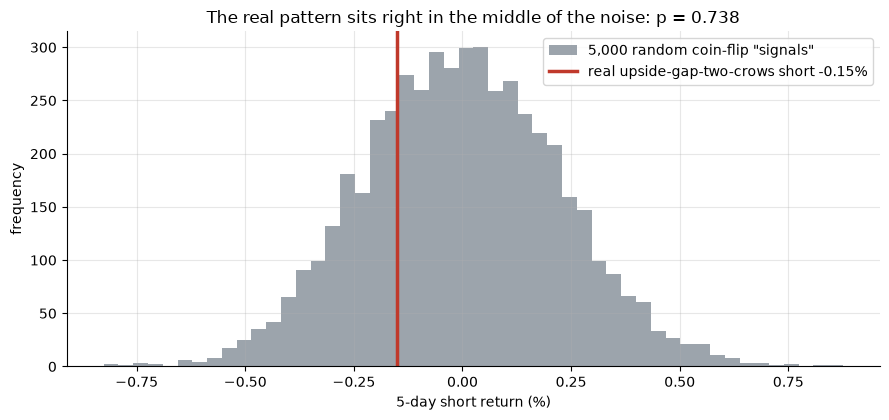

observed -0.15%   share of random fakes that beat it: p = 0.738


In [3]:
if HAVE_REAL:
    ev = st.collect_events(PANEL, 5)
    obs = float(ev['signed_ret'].mean())
    pl = st.placebo_pvalue(PANEL, 5, len(ev), obs, n_draws=5000)
    draws = pl['draws']*100; obsp = obs*100; pval = pl['p_value']
else:
    obsp = R['h5'][2]; pval = R['h5'][9]
    rng = np.random.default_rng(689); draws = rng.normal(0.0, 0.34, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='5,000 random coin-flip "signals"')
ax.axvline(obsp, c=RED, lw=2.5, label=f'real upside-gap-two-crows short {obsp:+.2f}%')
ax.set_xlabel('5-day short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real pattern sits right in the middle of the noise: p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obsp:+.2f}%   share of random fakes that beat it: p = {pval:.3f}')

With placebo *p* = **0.74**, the real pattern's return sits right where a large share of pure random coin-flip picks land too. There's no tail event here at all — the crows aren't special.

**Does the picture-perfect version save it?** Maybe an overlapping, casual gap is noise but the strict, true full-range gap — or only counting patterns that followed a *real* uptrend — is the genuine deal. Let's check both stricter recipes against a fair (unconditional-base) comparison.

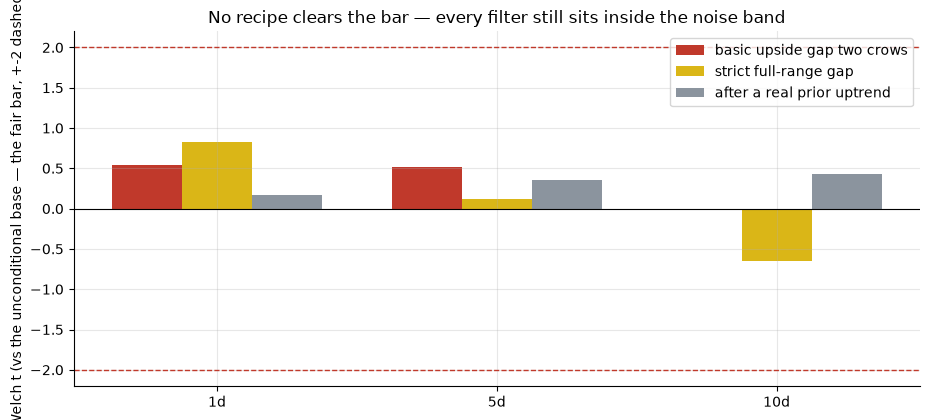

basic t: [0.55, 0.52, -0.01]
strict t: [0.83, 0.12, -0.65]
trend t: [0.17, 0.36, 0.43]


In [4]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, true_range_gap=True)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['t_welch'] for h in hs]
else:
    basic  = [R['h1'][8], R['h5'][8], R['h10'][8]]
    strict = [s[3] for s in R['strict']]; trend = [t[3] for t in R['trend']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic upside gap two crows')
ax.bar(x,      strict,.25, color=AMBER, label='strict full-range gap')
ax.bar(x+.25,  trend, .25, color=GREY, label='after a real prior uptrend')
ax.axhline(0, c='k', lw=.8); ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs the unconditional base — the fair bar, +-2 dashed)')
ax.set_title('No recipe clears the bar — every filter still sits inside the noise band')
ax.legend(); plt.tight_layout(); plt.show()
print('basic t:', [round(b,2) for b in basic]); print('strict t:', [round(s,2) for s in strict]); print('trend t:', [round(t,2) for t in trend])

No bar in that chart pokes above the dashed ±2 lines — the fair, drift-neutral test — under any of the three recipes. The legend doesn't hide in a stricter gap or a genuine uptrend filter; it simply isn't there.

## 5 · The verdict

- **Signal — None.** Measured fairly (against the basket's own unconditional day, not against zero), the upside-gap-two-crows short never clears the ±2 bar at any horizon. No single stock secretly carries it either — **0/26** individual tickers clear a corrected bar, and the two loudest names disagree on direction. There's no bearish edge.
- **Tradability — Mirage.** It's flat-to-negative **before** costs; once you add the spread and short borrow it's worse at every horizon. Nothing to deploy.
- **"Marks a top"? — Busted.** The famous "unfilled gap = exhaustion, the top is in" reading doesn't survive contact with the tape once you compare it to an ordinary day.

## 6 · Could you actually trade it? — no, and here's the kicker

The short is already flat-to-negative gross. Now add the real-world frictions — the spread paid on the round trip, plus borrow to hold a short. The bars only sink further.

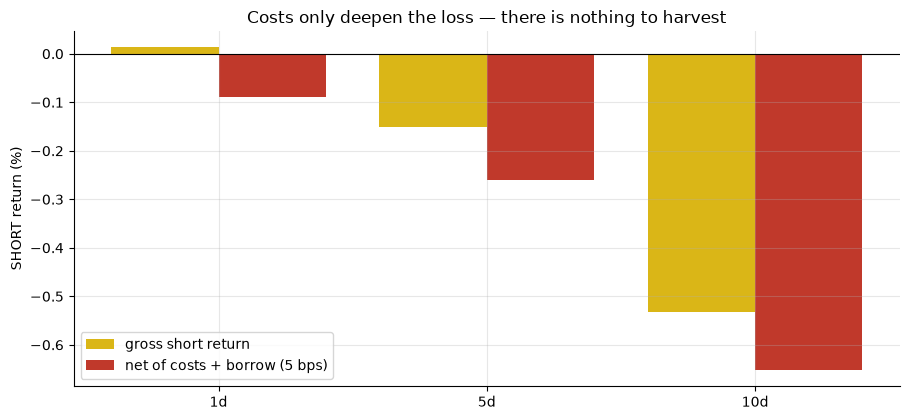

net short by horizon: {'1d': -0.089, '5d': -0.261, '10d': -0.652}


In [5]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [st.net_of_costs(st.summarize(PANEL, h, placebo=False)['mean'], h, cost_bps=5.0)*100 for h in hs]
else:
    g  = [R['h1'][2], R['h5'][2], R['h10'][2]]
    n5 = [R['h1'][10], R['h5'][10], R['h10'][10]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross short return')
ax.bar(x+.2, n5, .4, color=RED, label='net of costs + borrow (5 bps)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('SHORT return (%)'); ax.set_title('Costs only deepen the loss — there is nothing to harvest')
ax.legend(); plt.tight_layout(); plt.show()
print('net short by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,n5)})

At every horizon the **net** short is more negative than the gross — e.g. **-0.26%** at 5 days. There is no window where it pays. The only way to "make money" around an upside gap two crows is to do the **opposite** of the lore (don't short into the drop) — and even that residual is just the market's normal upward drift, not a tradeable pattern edge.

## 7 · Going further 🚪

- **Why does the naive comparison fool people?** Any short in an up-drifting market looks "significantly negative" against **zero** — with or without a gap-and-crows. That's why this study's certifying test compares the pattern's short to what the *same basket* earns on an ordinary day, not to zero. The [quants notebook](02_for_the_quants.ipynb) shows this exact trap live on a synthetic panel with a **known** zero edge.
- **The survivorship twist.** Our basket excludes names that actually topped, crashed and delisted — so we've **stacked the deck in the lore's favour** and it *still* fails.
- **The gap-pattern family.** [417-island-reversal](../../417-island-reversal/) needs *two* opposite gaps sealing a stranded cluster; [683-evening-star](../../683-evening-star/) needs only a small "star" body, not two full black crows; [408-three-black-crows](../../408-three-black-crows/) is three red candles with no gap at all — none of them run this study's specific figure.

*Think a stricter gap, a different universe, or a clever filter turns it green? Show the **net** short landing above the basket's own baseline with Welch *t* ≥ 2 — then we'll talk.*